In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/cleaned_supply_chain.csv")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [4]:
# Convert date columns
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

# Create shipping delay
df["Shipping_Delay"] = (
    df["shipping date (DateOrders)"] - df["order date (DateOrders)"]
).dt.days

# Time features
df["Order_Month"] = df["order date (DateOrders)"].dt.month
df["Order_Year"] = df["order date (DateOrders)"].dt.year

In [5]:
features = [
"Shipping Mode",
"Customer Segment",
"Order Region",
"Order Item Quantity",
"Sales",
"Order_Month",
"Days for shipment (scheduled)"
]

X = df[features]
y = df["Shipping_Delay"]

In [6]:
#encode cataegorical data
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X["Shipping Mode"] = encoder.fit_transform(X["Shipping Mode"])
X["Customer Segment"] = encoder.fit_transform(X["Customer Segment"])
X["Order Region"] = encoder.fit_transform(X["Order Region"])

C:\Users\shaik\AppData\Local\Temp\ipykernel_16484\3375581969.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Shipping Mode"] = encoder.fit_transform(X["Shipping Mode"])
C:\Users\shaik\AppData\Local\Temp\ipykernel_16484\3375581969.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Customer Segment"] = encoder.fit_transform(X["Customer Segment"])
C:\Users\shaik\AppData\Local\Temp\ipykernel_16484\3375581969.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
#cross Validation
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Random Forest CV MAE:", -rf_scores.mean())

Random Forest CV MAE: 0.9586908209303587


In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


In [13]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


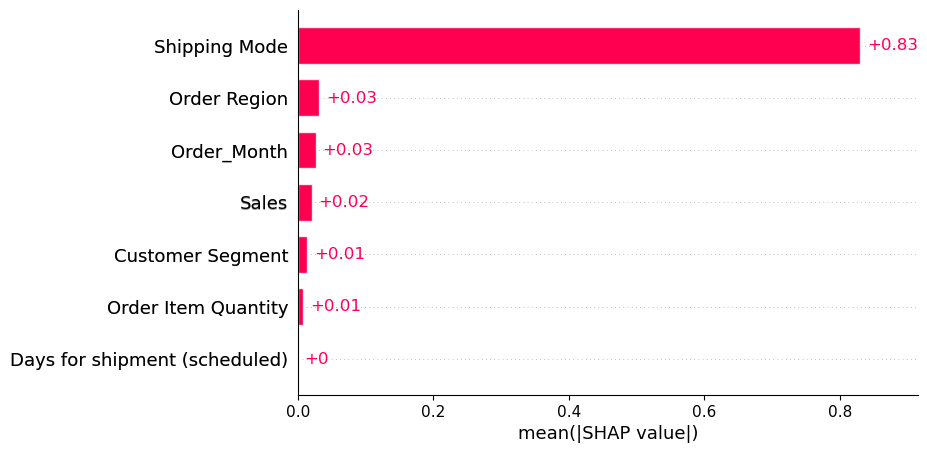

In [14]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [15]:
import pickle

with open("../models/final_supply_chain_model.pkl","wb") as f:
    pickle.dump(xgb_model,f)

In [16]:
import joblib

joblib.dump(xgb_model, "../models/supply_chain_delay_model.pkl")

print("Model saved successfully")

Model saved successfully
